In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- STEP 1: Set your file path ---
file_path = "void_halo_0.hdf5"

# --- STEP 2: Open the file ---
with h5py.File(file_path, "r") as f:

    # --- STEP 3: Show top-level structure ---
    print("\nTop-level keys (halo names):")
    halo_names = list(f.keys())
    print(halo_names)

    # --- STEP 4: Choose a halo ---
    halo = f[halo_names[0]]   # take the first halo
    print(f"\nExploring {halo_names[0]}...")

    # --- STEP 5: Show contents of the halo ---
    print("\nDatasets in this halo:")
    print(list(halo.keys()))

    print("\nAttributes of this halo:")
    print(list(halo.attrs.keys()))




Top-level keys (halo names):
['halo_0']

Exploring halo_0...

Datasets in this halo:
['SED_flux', 'SED_flux_density', 'SED_flux_density_with_noise', 'SED_flux_with_noise', 'SED_wav_angstroms', 'SED_wav_angstroms_with_noise', 'SED_wav_microns', 'SED_wav_microns_with_noise', 'Salpeter_IMF_SFR', 'Salpeter_IMF_SFR_with_noise', 'UV_continuum_slope', 'UV_continuum_slope_error', 'UV_continuum_slope_error_with_noise', 'UV_continuum_slope_with_noise', 'absolute_magnitude_UV', 'absolute_magnitude_UV_with_noise', 'angular_momentum', 'apparent_magnitude', 'apparent_magnitude_with_noise', 'bh_particle_IDs', 'color_band', 'color_band_with_noise', 'emission_lines', 'gas_mass', 'half_light_rad', 'half_light_rad_with_noise', 'image', 'image_with_noise', 'pop2_metallicity_fraction', 'pop2_stellar_age', 'pop2_stellar_angular_momentum', 'pop2_stellar_masses', 'pop2_stellar_positions', 'pop2_stellar_velocities', 'pop3_stellar_masses', 'position', 'sersic_error', 'sersic_error_with_noise', 'sersic_index', 

In [ ]:
#INTERESTING HALO PLOTS#

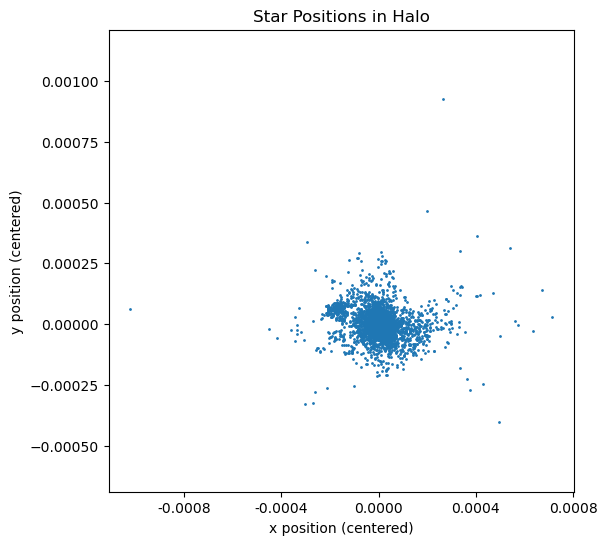

In [37]:
file_path = "void_halo_0.hdf5"

with h5py.File(file_path, "r") as f:
    halo = f[list(f.keys())[0]]

    if "pop2_stellar_positions" in halo:
        positions = halo["pop2_stellar_positions"][:]

        x = positions[:, 0]
        y = positions[:, 1]

        x_centered = x - np.mean(x)
        y_centered = y - np.mean(y)

        # --- ORIGINAL PLOT ---
        plt.figure(figsize=(6,6))
        plt.scatter(x_centered, y_centered, s=1)

        plt.axis("equal")
        plt.xlabel("x position (centered)")
        plt.ylabel("y position (centered)")
        plt.title("Star Positions in Halo")

        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
        plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

        plt.show()


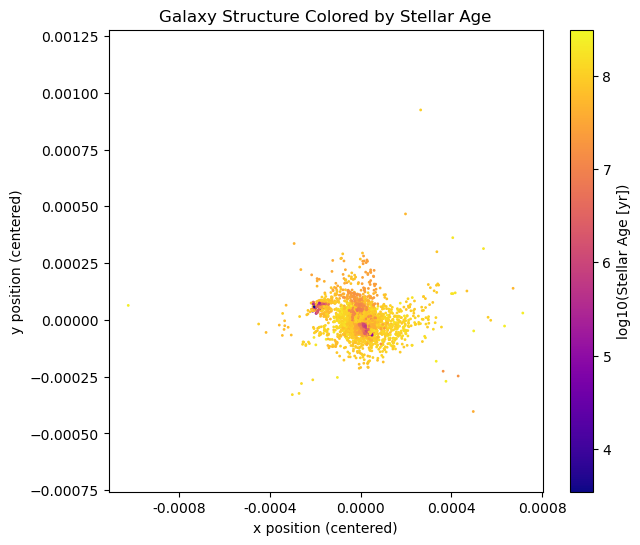

In [23]:
# --- EPIC PLOT: Stellar Structure Colored by Age ---

file_path = "void_halo_0.hdf5"

with h5py.File(file_path, "r") as f:
    halo = f[list(f.keys())[0]]

    # check BOTH datasets at once
    if "pop2_stellar_positions" in halo and "pop2_stellar_age" in halo:

        positions = halo["pop2_stellar_positions"][:]
        ages = halo["pop2_stellar_age"][:]

        # positions
        x = positions[:, 0]
        y = positions[:, 1]

        # center
        x_centered = x - np.mean(x)
        y_centered = y - np.mean(y)

        # log age for contrast
        log_age = np.log10(ages)

        plt.figure(figsize=(7,6))
        plt.scatter(x_centered, y_centered, c=log_age, s=1, cmap="plasma")

        cbar = plt.colorbar()
        cbar.set_label("log10(Stellar Age [yr])")

        plt.xlabel("x position (centered)")
        plt.ylabel("y position (centered)")
        plt.title("Galaxy Structure Colored by Stellar Age")
        
        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
        plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

        plt.axis("equal")
        plt.show()

    else:
        print("Required datasets not found.")

Filters: ['F150W', 'F200W', 'F277W', 'F356W', 'F444W']


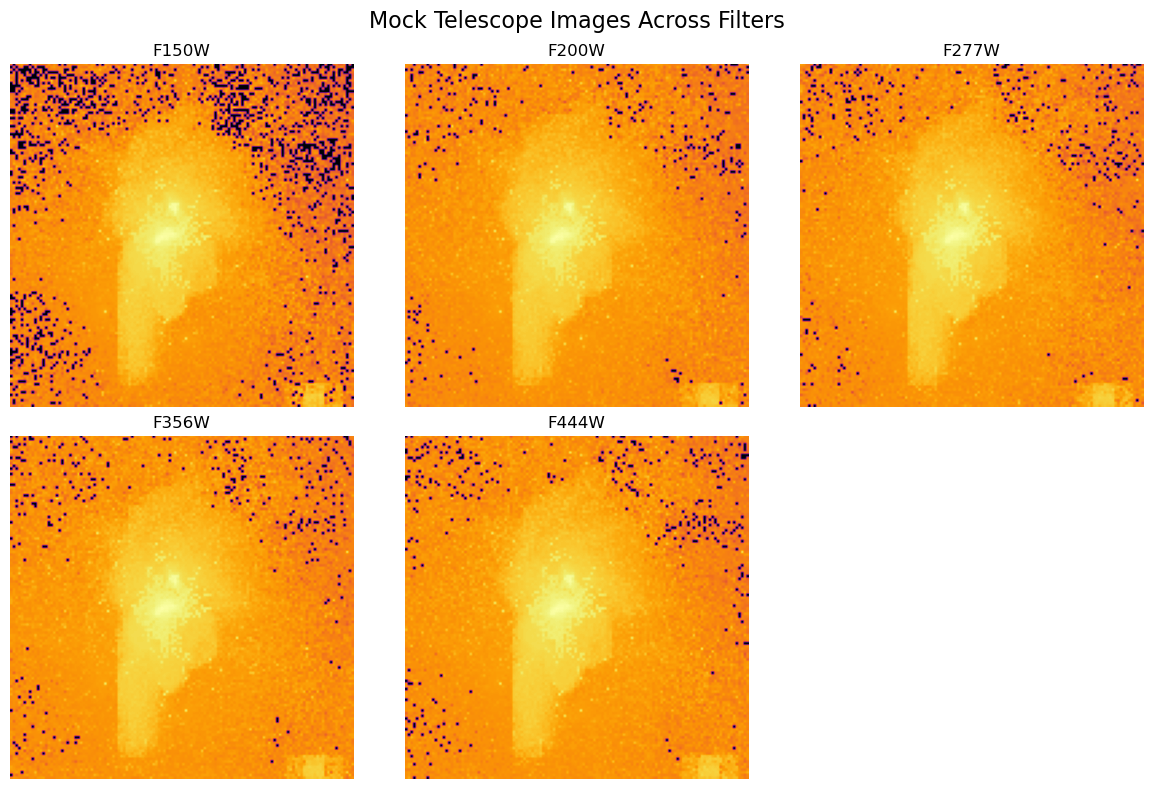

In [36]:


file_path = "void_halo_0.hdf5"

with h5py.File(file_path, "r") as f:
    halo = f[list(f.keys())[0]]

    if "image" in halo:

        image_group = halo["image"]
        filters = list(image_group.keys())

        print("Filters:", filters)

        n = len(filters)
        cols = 3
        rows = int(np.ceil(n / cols))

        plt.figure(figsize=(12, 4 * rows))

        for i, filt in enumerate(filters):
            img = image_group[filt][:]

            if img.ndim == 3:
                img = img[0]

            img_log = np.log10(img + 1e-10)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img_log, origin="lower", cmap="inferno")
            plt.title(filt)
            plt.axis("off")

        plt.suptitle("Mock Telescope Images Across Filters", fontsize=16)
        plt.tight_layout()
        plt.show()

    else:
        print("No image dataset found.")

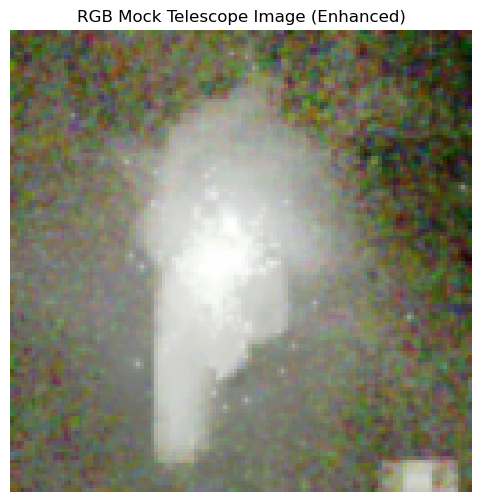

In [35]:


file_path = "void_halo_0.hdf5"

with h5py.File(file_path, "r") as f:
    halo = f[list(f.keys())[0]]

    if "image" in halo:

        img_group = halo["image"]

        red = img_group["F444W"][:]
        green = img_group["F277W"][:]
        blue = img_group["F150W"][:]

        if red.ndim == 3:
            red = red[0]
            green = green[0]
            blue = blue[0]

        # --- CLEAN ---
        red = np.clip(red, 1e-10, None)
        green = np.clip(green, 1e-10, None)
        blue = np.clip(blue, 1e-10, None)

        # --- LOG SCALE ---
        red = np.log10(red)
        green = np.log10(green)
        blue = np.log10(blue)

        stack = np.stack([red, green, blue])

        # tighter contrast stretch
        vmin = np.percentile(stack, 10)
        vmax = np.percentile(stack, 99.5)

        red = (red - vmin) / (vmax - vmin)
        green = (green - vmin) / (vmax - vmin)
        blue = (blue - vmin) / (vmax - vmin)

        red = np.clip(red, 0, 1)
        green = np.clip(green, 0, 1)
        blue = np.clip(blue, 0, 1)

        # --- LESS smoothing (important) ---
        red = gaussian_filter(red, sigma=0.7)
        green = gaussian_filter(green, sigma=0.7)
        blue = gaussian_filter(blue, sigma=0.7)

        # --- GAMMA STRETCH (this is the magic) ---
        gamma = 0.6
        red = red**gamma
        green = green**gamma
        blue = blue**gamma

        rgb = np.stack([red, green, blue], axis=-1)

        plt.figure(figsize=(6,6))
        plt.imshow(rgb, origin="lower")

        plt.title("RGB Mock Telescope Image (Enhanced)")
        plt.axis("off")

        plt.show()

    else:
        print("No image dataset found.")

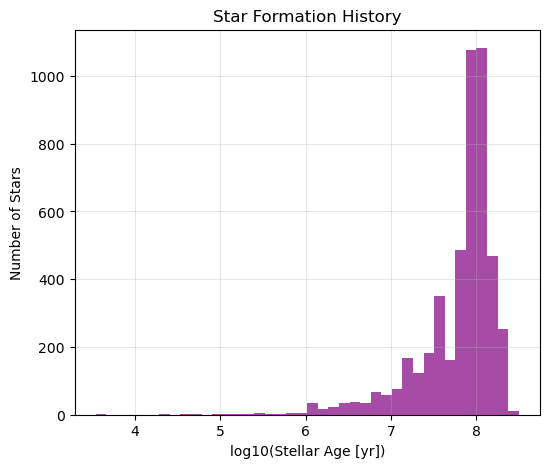

In [60]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# --- STAR FORMATION HISTORY ---

file_path = "void_halo_0.hdf5"

with h5py.File(file_path, "r") as f:
    halo = f[list(f.keys())[0]]

    if "pop2_stellar_age" in halo:

        ages = halo["pop2_stellar_age"][:]   # in years

        # remove any bad values
        ages = np.clip(ages, 1e-10, None)

        # convert to log scale
        log_ages = np.log10(ages)

        plt.figure(figsize=(6,5))
        plt.hist(log_ages, bins=40, color="purple", alpha=0.7)

        plt.xlabel("log10(Stellar Age [yr])")
        plt.ylabel("Number of Stars")
        plt.title("Star Formation History")

        plt.grid(alpha=0.3)
        plt.show()

    else:
        print("Dataset 'pop2_stellar_age' not found.")

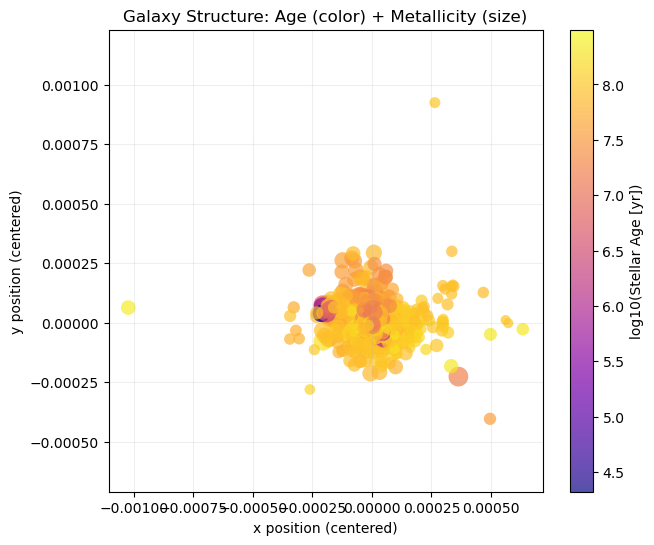

In [61]:
# --- FINAL SHOWSTOPPER (WHITE BACKGROUND) ---

import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "void_halo_0.hdf5"

with h5py.File(file_path, "r") as f:
    halo = f[list(f.keys())[0]]

    if ("pop2_stellar_positions" in halo and
        "pop2_stellar_age" in halo and
        "pop2_metallicity_fraction" in halo):

        pos = halo["pop2_stellar_positions"][:]
        age = halo["pop2_stellar_age"][:]
        metal = halo["pop2_metallicity_fraction"][:]

        # center positions
        x = pos[:, 0] - np.mean(pos[:, 0])
        y = pos[:, 1] - np.mean(pos[:, 1])

        # clean + log
        age = np.clip(age, 1e-10, None)
        metal = np.clip(metal, 1e-10, None)

        log_age = np.log10(age)
        log_metal = np.log10(metal)

        # --- size scaling ---
        metal_norm = (log_metal - np.min(log_metal)) / (np.max(log_metal) - np.min(log_metal) + 1e-10)
        sizes = 10 + 200 * metal_norm**2

        # --- downsample to reduce clutter ---
        N = len(x)
        idx = np.random.choice(N, size=int(0.4 * N), replace=False)

        x_plot = x[idx]
        y_plot = y[idx]
        age_plot = log_age[idx]
        size_plot = sizes[idx]

        # --- PLOT ---
        plt.figure(figsize=(7,6))

        scatter = plt.scatter(
            x_plot, y_plot,
            c=age_plot,
            s=size_plot,
            cmap="plasma",
            alpha=0.7,
            edgecolors="none"
        )

        cbar = plt.colorbar(scatter)
        cbar.set_label("log10(Stellar Age [yr])")

        plt.xlabel("x position (centered)")
        plt.ylabel("y position (centered)")
        plt.title("Galaxy Structure: Age (color) + Metallicity (size)")

        plt.axis("equal")

        # subtle grid (optional but nice)
        plt.grid(alpha=0.2)

        plt.show()

    else:
        print("Required datasets not found.")